<a href="https://colab.research.google.com/github/Yilalu/cnn_satellite_image_classification/blob/main/cnn_satellite_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolution Neural NetworkNetwork (CNN)

### Satellite image classification with CNN

#### Project Overview 

- This project implements a Convolutional Neural Network (CNN) using TensorFlow and Keras to perform multiclass classification of satellite imagery. The objective is to classify each satellite image into one of ten distinct land-cover classes. The overall workflow follows a standard deep learning pipeline, including data preparation, preprocessing, model development, training, evaluation, and model optimization.

In [1]:
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

2026-07-15 16:16:08.565807: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-15 16:16:08.637088: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-15 16:16:10.461006: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Dataset Preparation

- The satellite image dataset consists of approximately 27,000 labeled images distributed across 10 classes. Before model development, the dataset is organized into separate training, validation, and testing subsets to ensure an unbiased evaluation of model performance.

The dataset is divided as follows

    - Training Set (80%) – Used to train the CNN model.
    - Validation Set (10%) – Used to monitor the learning process and tune model hyperparameters.
    - Testing Set (10%) – Used only for the final performance evaluation.

- The goal is to train a CNN that can accurately identify the correct class for every input image.
    - AnnualCrop, 
    - Forest, 
    - HerbaceousVegetation
    - Highway
    - Industrial
    - Pasture
    - PermanentCrop
    - Residential
    - River
    - SeaLake

In [3]:
# CONFIGURATION
DATA_DIR= "satellite_data"
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 64
NUM_CLASSES = 10

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
# load the dataset
all_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)
print("Dataset loaded successfully.")
class_names = all_dataset.class_names
print("Number of classes:", len(class_names))
print("Classes found:", class_names)

# Let's print the number of images in each class
class_counts = {class_name: 0 for class_name in class_names}

for images, labels in all_dataset:
    for label in labels.numpy():
        class_counts[class_names[label]] += 1
print("Number of images in each class:")
for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")


Found 27000 files belonging to 10 classes.


I0000 00:00:1784147392.686103   76692 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Dataset loaded successfully.
Number of classes: 10
Classes found: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of images in each class:
AnnualCrop: 3000
Forest: 3000
HerbaceousVegetation: 3000
Highway: 2500
Industrial: 2500
Pasture: 2000
PermanentCrop: 2500
Residential: 3000
River: 2500
SeaLake: 3000


2026-07-15 16:29:53.956673: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [6]:
try:
    # 80% of the images are used for training.
    train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    color_mode="rgb",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
    )
    # The remaining 20% are left for validation and evaluation.
    remainder_ds = tf.keras.utils.image_dataset_from_directory(
        DATA_DIR,
        labels="inferred",
        label_mode="int",
        validation_split=0.2,
        subset="validation",
        color_mode="rgb",
        seed=SEED,
        image_size=IMAGE_SIZE,
        batch_size=None,
        shuffle=True
    )

    # Split that 20% in half: 10% for validation and 10% for a held-out test set.
    valid_ds, test_ds = tf.keras.utils.split_dataset(remainder_ds, left_size=0.5)

    valid_ds = valid_ds.batch(BATCH_SIZE)
    test_ds = test_ds.batch(BATCH_SIZE)
except Exception as e:
    print("Error loading dataset:", e)
    exit()


Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.


2026-07-15 16:30:09.727708: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [7]:
# Let's convert our image dataset to a NumPy array for easier manipulation

for images, labels in train_ds.take(1):
    train_images = images.numpy().astype("uint8")
    train_labels = labels.numpy().astype("int32")
for images, labels in valid_ds.take(1):
    valid_images = images.numpy().astype("uint8")
    valid_labels = labels.numpy().astype("int32")

# Now we can check the shapes of our training and validation datasets
print("Training images shape:", train_images.shape)
print("Training labels shape:", train_labels.shape)
print("Validation images shape:", valid_images.shape)
print("Validation labels shape:", valid_labels.shape)


Training images shape: (64, 128, 128, 3)
Training labels shape: (64,)
Validation images shape: (64, 128, 128, 3)
Validation labels shape: (64,)


2026-07-15 16:30:35.265245: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [8]:
# Now let's see what the  numbers for the last 20 images in the training dataset are
print("Last 20 training labels:", train_labels[-20:])
print("Last 20 validation labels:", valid_labels[-20:])

Last 20 training labels: [2 7 9 2 1 9 8 3 8 3 4 4 5 0 1 6 4 1 1 9]
Last 20 validation labels: [9 0 7 9 6 1 9 1 8 8 8 6 1 2 7 1 1 0 2 8]


In [9]:
# Let's count the number of images in each class across the FULL training, validation,
# and test sets to confirm the split is balanced (every class should appear in all three).
def count_classes(dataset):
    counts = {class_name: 0 for class_name in class_names}
    for images, labels in dataset:
        for label in labels.numpy():
            counts[class_names[label]] += 1
    return counts

for name, dataset in [("training", train_ds), ("validation", valid_ds), ("test", test_ds)]:
    print("*"*40)
    print(f"Class count in full {name} set")
    print("*"*40)
    for class_name, count in count_classes(dataset).items():
        print(f"{class_name}: {count}")

****************************************
Class count in full training set
****************************************
AnnualCrop: 2403
Forest: 2400
HerbaceousVegetation: 2443
Highway: 2007
Industrial: 1988
Pasture: 1626
PermanentCrop: 2009
Residential: 2393
River: 1953
SeaLake: 2378
****************************************
Class count in full validation set
****************************************
AnnualCrop: 298
Forest: 291
HerbaceousVegetation: 253
Highway: 247
Industrial: 277
Pasture: 200
PermanentCrop: 234
Residential: 326
River: 265
SeaLake: 309
****************************************
Class count in full test set
****************************************
AnnualCrop: 299
Forest: 309
HerbaceousVegetation: 304
Highway: 246
Industrial: 235
Pasture: 174
PermanentCrop: 257
Residential: 281
River: 282
SeaLake: 313


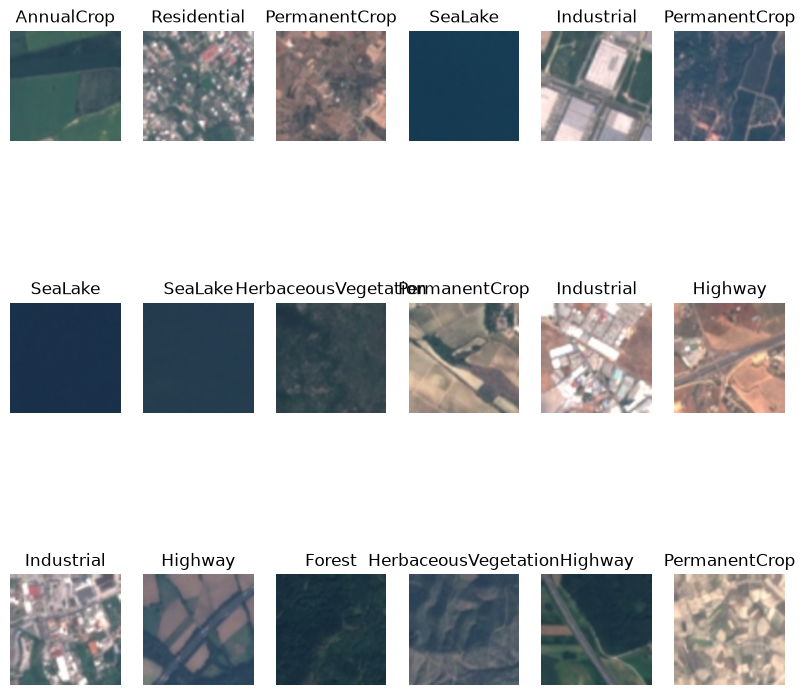

In [10]:
# Let's visualize some of the images in the training dataset along with their labels to ensure that the data is loaded correctly.
plt.figure(figsize=(10, 10))
for i in range(18):
    ax = plt.subplot(3, 6, i + 1)
    plt.imshow(train_images[i].astype("uint8"))
    plt.title(class_names[train_labels[i]])
    plt.axis("off")
plt.show()

### Dataset Preprocessing 

- Data Normalization
- Data Augmentation
- Pipeline Optimization

The pixel values are normalized from the range **0–255** to **0–1** using a rescaling layer. Normalization improves numerical stability during training and helps the model converge more efficiently.


Data augmentation is applied only to the training dataset to increase the diversity of the training images and reduce overfitting. Random transformations such as flipping, rotation, and zooming help the model learn features that are more robust to variations in satellite imagery.

The TensorFlow data pipeline is optimized to improve training performance. The training dataset is shuffled to randomize the order of the images, while caching and prefetching are used to reduce data loading time and improve GPU utilization during training.

In [11]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"), # Flip images horizontally with 50% probability
    tf.keras.layers.RandomRotation(0.1),     # Rotate images by up to 10% of a full rotation
    tf.keras.layers.RandomZoom(0.1)          # Zoom into images by up to 10%
])

AUTOTUNE = tf.data.AUTOTUNE # This allows TensorFlow to automatically tune the performance of the data loading pipeline.

train_ds = (
    train_ds
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
) # Prefetch data for optimal performance

val_ds = (
    valid_ds
    .cache()
    .prefetch(AUTOTUNE)
) # Prefetch data for optimal performance

test_ds = (
    test_ds
    .cache()
    .prefetch(AUTOTUNE)
) # Held out for final evaluation only - not touched during training or tuning

### Build the model

A Convolutional Neural Network (CNN) is developed to classify satellite images into 10 different classes. CNNs are effective for image classification because they can automatically learn spatial features such as edges, textures, and patterns from images.

The model consists of multiple convolutional layers followed by max-pooling layers to extract and reduce spatial features. A dropout layer is included to reduce overfitting, and the final dense layer uses a softmax activation function to output the probability distribution across the 10 classes.

The input images have dimensions of 128 × 128 pixels with 3 RGB channels.

In [12]:
image_model = tf.keras.Sequential([
    # Input layer with the shape of the images
    tf.keras.layers.Input(shape=(128, 128, 3)),  # Input layer with the shape of the images

    # Normalization layer to scale pixel values to [0, 1]
    normalization_layer,   
    # Data augmentation layer to apply random transformations to the images during training
    data_augmentation,

    # First Convolutional layer with 32 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolutional layer with 64 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional layer with 128 filters, a kernel size of 3x3, and ReLU activation
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    # MaxPooling layer to reduce the spatial dimensions of the feature maps
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten layer to convert the 2D feature maps into a 1D feature vector
    tf.keras.layers.Flatten(),

    # Dense layer with 128 units and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),

    # Output layer with NUM_CLASSES units and softmax activation for multi-class classification
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')

], name="image_model")

# Compile the model with Adam optimizer, sparse categorical crossentropy loss, and accuracy metric
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Let's print the model summary to see the architecture and number of parameters
image_model.summary()

Model: "image_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,970 (16.36 MB)

 Trainable params: 4,288,970 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

### Train the Baseline Model

This is the baseline CNN, trained as-is with no hyperparameter tuning or architecture changes. `EarlyStopping` monitors validation loss so training stops once it stops improving, and the best weights are restored automatically. This run sets the reference performance that later tuning passes will be compared against.

The held-out test set (`test_ds`) is not used here, it stays untouched until a final model is selected.

In [13]:
EPOCHS = 30 # Generous upper bound - EarlyStopping will halt training once val_loss stops improving

# Stop training when validation loss stops improving, and roll back to the best weights seen
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# Train the baseline model and keep the history for the curves below
history = image_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/30


/home/gbelew/revature/project/cnn_satellite_image_classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-07-15 16:31:27.136140: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92400


338/338 ━━━━━━━━━━━━━━━━━━━━ 27s 52ms/step - accuracy: 0.3714 - loss: 1.6974 - val_accuracy: 0.5100 - val_loss: 1.3401
Epoch 2/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 24s 70ms/step - accuracy: 0.5549 - loss: 1.2519 - val_accuracy: 0.5752 - val_loss: 1.1508
Epoch 3/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 29s 87ms/step - accuracy: 0.6035 - loss: 1.1026 - val_accuracy: 0.6522 - val_loss: 1.0097
Epoch 4/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 30s 87ms/step - accuracy: 0.6446 - loss: 0.9994 - val_accuracy: 0.6811 - val_loss: 0.8996
Epoch 5/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 25s 72ms/step - accuracy: 0.6712 - loss: 0.9326 - val_accuracy: 0.7230 - val_loss: 0.8261
Epoch 6/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 62ms/step - accuracy: 0.6952 - loss: 0.8622 - val_accuracy: 0.7181 - val_loss: 0.8089
Epoch 7/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 43s 68ms/step - accuracy: 0.7134 - loss: 0.8093 - val_accuracy: 0.7326 - val_loss: 0.7821
Epoch 8/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.7287 - loss: 0.7695 - val_accurac

#### Baseline Training Curves

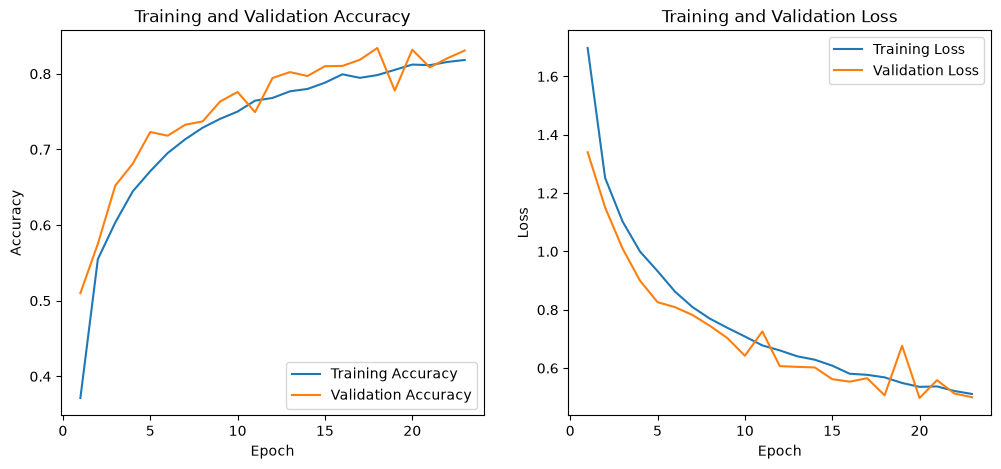

In [14]:
# Pull the per-epoch metrics out of the history object
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

### Improved Model — Training Stability Fixes

The baseline model struggled to learn: validation accuracy stalled around 50% and the loss kept climbing across epochs, which points to unstable training. This section rebuilds the same CNN with three targeted changes to stabilize learning, while keeping everything else (dataset, normalization, and augmentation) the same.

- **BatchNormalization after each convolution** – keeps the layer activations well-scaled as they flow through the network.
- **GlobalAveragePooling2D instead of Flatten** – the baseline's Flatten -> Dense connection held over 4 million parameters in a single layer, most of the model's weight. Global average pooling collapses each feature map to one value, cutting those parameters dramatically and reducing overfitting.
- **Higher learning rate (1e-3) with ReduceLROnPlateau** – BatchNorm allows a larger, faster learning rate, and the scheduler automatically lowers it whenever validation loss plateaus so the model can keep refining.

In [15]:
image_model_v2 = tf.keras.Sequential([
    # Input layer with the shape of the images
    tf.keras.layers.Input(shape=(128, 128, 3)),

    # Normalization layer to scale pixel values to [0, 1]
    normalization_layer,
    # Data augmentation layer to apply random transformations to the images during training
    data_augmentation,

    # First Convolutional block: Conv -> BatchNorm -> MaxPooling
    # BatchNormalization stabilizes training
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Second Convolutional block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Third Convolutional block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # GlobalAveragePooling replaces Flatten: it collapses each feature map to a single
    # value, cutting millions of dense-layer parameters and reducing overfitting
    tf.keras.layers.GlobalAveragePooling2D(),

    # Dense layer with 128 units and ReLU activation
    tf.keras.layers.Dense(128, activation='relu'),
    # Dropout layer to further reduce overfitting
    tf.keras.layers.Dropout(0.3),

    # Output layer with NUM_CLASSES units and softmax activation for multi-class classification
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')

], name="image_model_v2")

# Compile with a higher learning rate (1e-3) - BatchNorm makes this stable, and
# ReduceLROnPlateau will lower it automatically when needed
image_model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)

# Print the model summary to see the architecture and number of parameters
image_model_v2.summary()

Model: "image_model_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [18]:
EPOCHS = 30

# Stop training when validation loss stops improving, and roll back to the best weights seen
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Drop the learning rate when val_loss plateaus so the model can keep refining
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5, # Halve the learning rate each time it triggers
    patience=2, # Wait 2 epochs with no improvement before reducing
    min_lr=1e-6
)

# Train the improved model and keep the history for the curves below
history_v2 = image_model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 40s 110ms/step - accuracy: 0.6432 - loss: 1.0198 - val_accuracy: 0.1559 - val_loss: 4.2781 - learning_rate: 0.0010
Epoch 2/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 42s 124ms/step - accuracy: 0.7445 - loss: 0.7287 - val_accuracy: 0.4574 - val_loss: 1.7212 - learning_rate: 0.0010
Epoch 3/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 43s 127ms/step - accuracy: 0.7766 - loss: 0.6269 - val_accuracy: 0.6056 - val_loss: 1.2367 - learning_rate: 0.0010
Epoch 4/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 76s 110ms/step - accuracy: 0.8161 - loss: 0.5354 - val_accuracy: 0.5481 - val_loss: 1.8740 - learning_rate: 0.0010
Epoch 5/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 40s 118ms/step - accuracy: 0.8427 - loss: 0.4635 - val_accuracy: 0.8100 - val_loss: 0.5427 - learning_rate: 0.0010
Epoch 6/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 41s 121ms/step - accuracy: 0.8631 - loss: 0.3996 - val_accuracy: 0.7219 - val_loss: 0.7627 - learning_rate: 0.0010
Epoch 7/30
338/338 ━━━━━━━━━━━━━━━━━━━━ 41s 122ms/step - accuracy: 0.8

#### Improved Model Training Curves

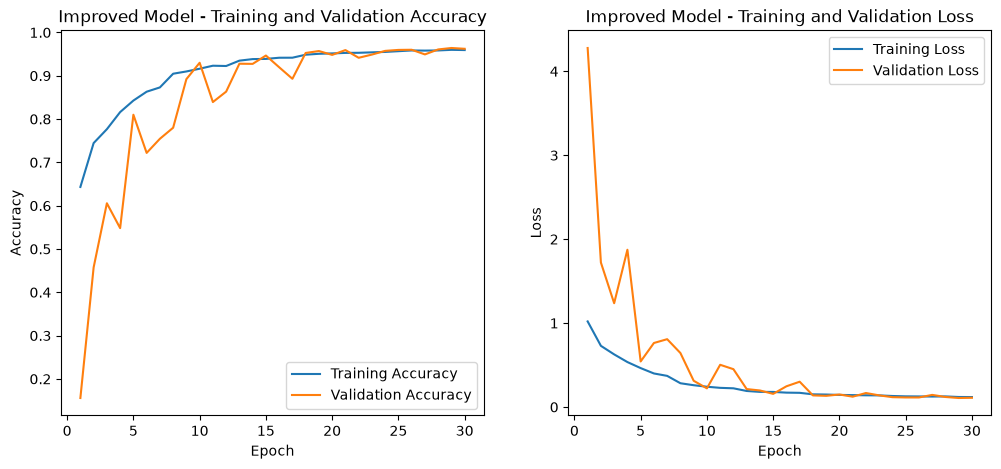

In [19]:
# Pull the metrics for the improved model
acc = history_v2.history['accuracy']
val_acc = history_v2.history['val_accuracy']
loss = history_v2.history['loss']
val_loss = history_v2.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Improved Model - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Improved Model - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

### Final Evaluation on the Held-Out Test Set

With the improved model training well, we now evaluate it once on the test set. This gives an unbiased estimate of real-world performance.

We look at three things:

- **Test accuracy and loss** - overall performance on unseen data.
- **Confusion matrix** – which land-cover classes get confused with each other
- **Classification report** – per-class precision, recall, and F1-score, which reveal weak classes that a single accuracy number would hide.

In [20]:
# Evaluate the final model on the held-out test set - used here for the first time
test_loss, test_accuracy = image_model_v2.evaluate(test_ds)
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss:     {test_loss:.4f}")

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9607 - loss: 0.1045
Test accuracy: 0.9607
Test loss:     0.1045


In [21]:
# Collect the true labels and the model's predicted labels across the whole test set
y_true = []
y_pred = []
for images, labels in test_ds:
    probs = image_model_v2.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))  # Predicted class = highest-probability class
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("Collected predictions for", len(y_true), "test images.")

Collected predictions for 2700 test images.


2026-07-15 17:10:55.911823: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


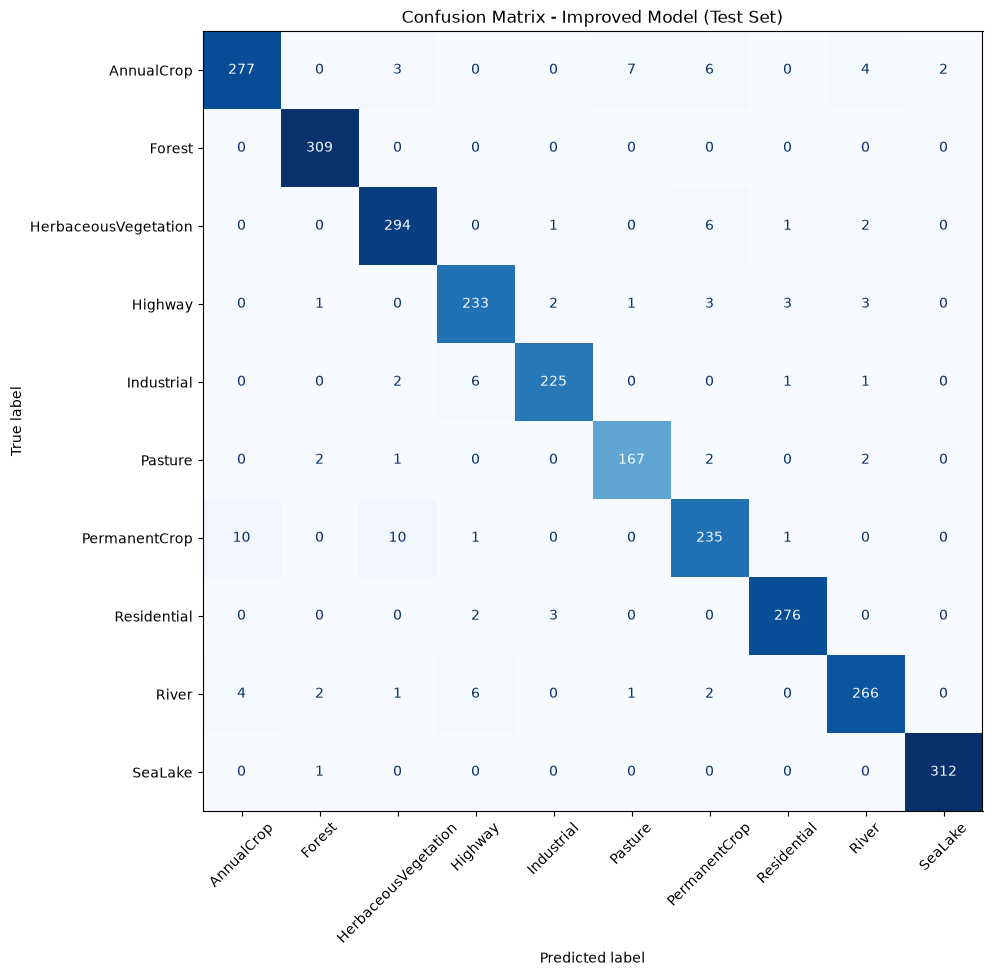

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Build the confusion matrix to see which classes get mixed up with each other
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=False)
plt.title('Confusion Matrix - Improved Model (Test Set)')
plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import classification_report

# Per-class precision, recall, and F1-score on the test set.
report = classification_report(y_true, y_pred, target_names=class_names, digits=3)
print(report)

                      precision    recall  f1-score   support

          AnnualCrop      0.952     0.926     0.939       299
              Forest      0.981     1.000     0.990       309
HerbaceousVegetation      0.945     0.967     0.956       304
             Highway      0.940     0.947     0.943       246
          Industrial      0.974     0.957     0.966       235
             Pasture      0.949     0.960     0.954       174
       PermanentCrop      0.925     0.914     0.920       257
         Residential      0.979     0.982     0.980       281
               River      0.957     0.943     0.950       282
             SeaLake      0.994     0.997     0.995       313

            accuracy                          0.961      2700
           macro avg      0.959     0.959     0.959      2700
        weighted avg      0.961     0.961     0.961      2700



### Saving The Model

In [28]:
# Now let's save the model to disk so we can load it later without retraining
model_save_path = "saved_models/image_model_v2.keras"
image_model_v2.save(model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to saved_models/image_model_v2.keras
